<a href="https://colab.research.google.com/github/AndreiDragomir07/COS484_A1_P2/blob/main/Copy_of_A1P2_Classification_(COS484_S2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook for Programming Question 2
Welcome to the programming portion of the assignment! Each assignment throughout the semester will have a written portion and a programming portion. We will be using [Google Colab](https://colab.research.google.com/notebooks/intro.ipynb#recent=true), so if you have never used it before, take a quick look through this introduction: [Working with Google Colab](https://docs.google.com/document/d/1LlnXoOblXwW3YX-0yG_5seTXJsb3kRdMMRYqs8Qqum4/edit?usp=sharing).

We'll also be programming in Python, which we will assume a basic familiarity with. Python has fantastic community support and we'll be using numerous packages for machine learning (ML) and natural language processing (NLP) tasks.

### Learning Objectives
In this problem we will implement logistic regression and test it on a sentiment analysis dataset.

### Data Loading and Feature Extraction

##### You will need to implement a method that processes raw text into feature vectors by mapping vocabulary terms to unique indices. Your implementation needs to support Unigram extraction, where features represent individual word counts, as well as Bigram extraction, where features represent consecutive word pair counts. Make sure your setup correctly handles feature indexing so that the same mapping is applied to both training and development data.

In [ ]:
import requests

def load_dataset(url):
    """
    Loads a dataset from a given URL, parsing each line into a label and a list of tokens.
    Skips the label (0 or 1) at the beginning of each line.

    Args:
        url (str): The URL of the dataset.

    Returns:
        list: A list of tuples, where each tuple contains (label, list_of_tokens).
              Labels are integers (0 or 1), and tokens are strings.
    """
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for HTTP errors
    lines = response.text.strip().split('\n')

    parsed_data = []
    for line in lines:
        if not line:  # Skip empty lines
            continue

        parts = line.split(' ', 1) # Split only on the first space
        if len(parts) < 2:
            # Handle lines that might only contain a label or are malformed
            continue

        label_str = parts[0]
        text_str = parts[1]

        try:
            label = int(label_str)
            # Tokenize by whitespace. The text is already pre-tokenized by whitespace as per instructions.
            tokens = text_str.split()
            parsed_data.append((label, tokens))
        except ValueError:
            # Skip lines where label is not an integer
            continue

    return parsed_data

training_tokens = load_dataset("https://princeton-nlp.github.io/cos484/assignments/a1/train.txt")
development_tokens = load_dataset("https://princeton-nlp.github.io/cos484/assignments/a1/dev.txt")

print(training_tokens)


In [2]:
import numpy as np
import scipy.sparse as sp # Import scipy.sparse

class FeatureExtraction:
    def __init__(self):
        self.token_to_idx = {}
        self.idx_to_token = []
        self.vocab_size = 0

    def build_vocabulary(self, training_tokens):
        """
        Builds the token vocabulary from a list of tokenized texts.

        Args:
            training_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
        for review in training_tokens:
            for token in review[1]: # review[1] contains the list of tokens
                if token not in self.token_to_idx:
                    self.token_to_idx[token] = self.vocab_size
                    self.idx_to_token.append(token)
                    self.vocab_size += 1
        print(f"Vocabulary built with {self.vocab_size} unique tokens.")

    def unigram_extraction(self, input_tokens):
        """
        Maps a given dataset onto a unigram array, which transforms
        all datapoints into a tuple consisting of an integer (0 or 1) and then
        a numpy array representing the counts of each of the tokens in the
        vocabulary that appear in the given datapoint

        Returns a list of tuples, where each tuple consists of an integer (0 or 1) and then
        a numpy array of size the same as the vocab representing the counts
        of each of the tokens in the vocabulary that appear in the given datapoint

        Checks whether a token read can be found in the vocabulary. If it
        cannot be found, dismiss it

        Args:
            self
            input_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
        extracted_features = []
        for label, tokens_list in input_tokens:
            feature_vector = np.zeros(self.vocab_size, dtype=int)
            for token in tokens_list:
                if token in self.token_to_idx:
                    idx = self.token_to_idx[token]
                    feature_vector[idx] += 1
            extracted_features.append((label, feature_vector))
        return extracted_features


    def bigram_extraction(self, input_tokens):
      """
        Maps a given dataset onto a bigram matrix, which transforms
        all datapoints into a tuple consisting of an integer (0 or 1) and then
        a numpy matrix representing the counts of each of the bigrams
        that appear in the given datapoint

        Returns a list of tuples, where each tuple consists of an integer (0 or 1) and then
        a numpy square matrix of size the same as the vocab representing the counts
        of each of the tokens in the vocabulary that appear in the given datapoint

        Checks whether a token read can be found in the vocabulary. If it
        cannot be found, dismiss it

        Args:
            self
            input_tokens (list): A list of tuples,
            where each tuple consists of an integer (0 or 1)
            and of a list of tokens (e.g., [[token1, token2], ...]).
        """
      extracted_features = []
      for label, tokens_list in input_tokens:
          # Use a dictionary to store bigram counts efficiently before converting to sparse format
          bigram_counts_dict = {}
          for i in range(len(tokens_list) - 1):
              token1 = tokens_list[i]
              token2 = tokens_list[i+1]

              if token1 in self.token_to_idx and token2 in self.token_to_idx:
                  idx1 = self.token_to_idx[token1]
                  idx2 = self.token_to_idx[token2]
                  # Map the bigram (idx1, idx2) to a single linear index
                  linear_idx = idx1 * self.vocab_size + idx2
                  bigram_counts_dict[linear_idx] = bigram_counts_dict.get(linear_idx, 0) + 1

          # Create a sparse vector (CSR matrix with 1 row) from the dictionary
          indices = np.array(list(bigram_counts_dict.keys()))
          data = np.array(list(bigram_counts_dict.values()))

          if len(indices) > 0:
            sparse_feature_vector = sp.csr_matrix((data, (np.zeros_like(indices), indices)),
                                                  shape=(1, self.vocab_size * self.vocab_size),
                                                  dtype=int)
          else:
            # Handle cases where there are no bigrams for a document
            sparse_feature_vector = sp.csr_matrix((1, self.vocab_size * self.vocab_size), dtype=int)

          extracted_features.append((label, sparse_feature_vector))
      return extracted_features

features = FeatureExtraction()
features.build_vocabulary(training_tokens)
vocab_size = features.vocab_size
training_unigram_features = features.unigram_extraction(training_tokens)
training_bigram_features = features.bigram_extraction(training_tokens)

Vocabulary built with 14828 unique tokens.


### Model Implementation

You should implement a class that supports the logistic regression logic. This includes:
*   **Initialization**: A function to initialize the model parameters (weights and biases) as well as hyperparameters (including the learning rate, regularization parameter, and number of epochs).
*   **Optimization**: A training method that iterates through the dataset, calculates the gradient of the loss function for each example or batch, and updates the parameters using your chosen optimization function (we suggest using Stochastic Gradient Descent or Mini-batch SGD for efficiency).
*   **Inference**: A function that outputs the model's prediction for a single example.

In [6]:
import numpy as np
import scipy.sparse as sp

class LogisticRegression:
    def __init__(self, data_dim, reg_param, learning_rate, training_tokens):
        self.dim = data_dim
        # Initialize weights to small random values and bias to 0
        self.weights = np.random.randn(data_dim) * 0.01 # Small random values for weights
        self.bias = 0.0 # Bias initialized to zero

        self.reg_param = reg_param
        self.learning_rate = learning_rate
        self.training_tokens = training_tokens # This will be a list of (label, feature_vector) tuples

    def logit(self, input_data):
      '''
      It calculates the logit value of a data point based on the weight
      and bias and using a sigmoid function.
      Args:
          self
          input_data: tuple - first element is true label, second
          element is a numpy array (for unigrams) or a scipy.sparse matrix (for bigrams)
          of dimension self.data_dim
      '''
      # input_data[1] is the feature vector
      feature_vector = input_data[1]
      if sp.issparse(feature_vector):
          # For sparse feature vectors (bigrams), perform dot product efficiently
          # The result of dot product with a (1, N) sparse matrix and (N,) dense vector is a (1,) array
          z = feature_vector.dot(self.weights)[0] + self.bias
      else:
          # For dense feature vectors (unigrams)
          z = np.dot(self.weights, feature_vector) + self.bias
      # Sigmoid function
      return 1 / (1 + np.exp(-z))

    def total_loss(self):
      '''
      It calculates the total loss for all the self.input_tokens using a
      binary cross-entropy loss formula and an additional penalty term
      from l2 regularization on the weight vector (exclude the bias)
      Args:
          self

      '''
      total_loss_val = 0
      for label, feature_vector in self.training_tokens:
          prediction = self.logit((label, feature_vector))
          # Clip predictions to avoid log(0) errors
          prediction = np.clip(prediction, 1e-10, 1 - 1e-10)
          total_loss_val += - (label * np.log(prediction) + (1 - label) * np.log(1 - prediction))

      # Add L2 regularization to weights (excluding bias)
      total_loss_val += 0.5 * self.reg_param * np.sum(self.weights**2)
      return total_loss_val

    def SGD_update(self, stochastic_perc):
        '''
      Performs a stochastic gradient descent update to the weight vector
      and bias by randomly selecting stochastic_perc percent of the data
      points and applying gradient descent on them (also including the
      gradient that comes from the regularization term)

      Uses logit method to calculate the gradients faster
      Args:
          self
          stochastic_perc: percentage of data points to be included in the
          stochastic gradient descent step
      '''
        num_samples = len(self.training_tokens)
        num_stochastic_samples = int(num_samples * stochastic_perc)

        # Randomly select a subset of training tokens
        indices = np.random.choice(num_samples, num_stochastic_samples, replace=False)
        stochastic_samples = [self.training_tokens[i] for i in indices]

        grad_weights = np.zeros_like(self.weights)
        grad_bias = 0.0

        for label, feature_vector in stochastic_samples:
            prediction = self.logit((label, feature_vector))
            error = prediction - label # (y_hat - y)

            grad_bias += error
            if sp.issparse(feature_vector):
                # Update only non-zero elements of grad_weights using sparse data
                # feature_vector is a (1, N) sparse matrix
                # Its .data contains the non-zero values
                # Its .indices contains the column indices of those values
                grad_weights[feature_vector.indices] += error * feature_vector.data
            else:
                grad_weights += error * feature_vector

        # Add regularization gradient to weights (excluding bias)
        grad_weights += self.reg_param * self.weights

        # Update weights and bias
        self.weights -= self.learning_rate * grad_weights
        self.bias -= self.learning_rate * grad_bias

    def predictions(self, input_tokens):
      '''
          Based on the current values for the weights and bias, returns a
          numpy array of the predicted labels for all the input data

      '''
      predictions_list = []
      for _, feature_vector in input_tokens:
          probability = self.logit((None, feature_vector)) # label is not needed for prediction
          predictions_list.append(1 if probability >= 0.5 else 0)
      return np.array(predictions_list)

    def accuracy(self, input_tokens):
        '''
            Returns the accuracy of the model as the percentage of data points
            that have been labeled correctly. Calls function predictions and
            also obtains a numpy array for the true labels from
            self.training_tokens to be used for accuracy calculation
        '''
        true_labels = np.array([label for label, _ in input_tokens])
        predicted_labels = self.predictions(input_tokens)

        correct_predictions = np.sum(true_labels == predicted_labels)
        total_predictions = len(true_labels)
        return correct_predictions / total_predictions

lr = 0.001
epochs = 100

unigram_model = LogisticRegression(data_dim=vocab_size, reg_param=0,
          learning_rate=lr, training_tokens= training_unigram_features)

# List to store loss values over epochs
unigram_train_accuracies = []
unigram_dev_accuracies = []

development_unigram_features = features.unigram_extraction(development_tokens)

for epoch in range(epochs):
    # Perform SGD step
    unigram_model.SGD_update(stochastic_perc=0.1)

    # Calculate and store accuracies
    train_acc = unigram_model.accuracy(training_unigram_features)
    dev_acc = unigram_model.accuracy(development_unigram_features)
    unigram_train_accuracies.append(train_acc)
    unigram_dev_accuracies.append(dev_acc)

    if (epoch + 1) % 10 == 0:
       print(f"Unigram Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc:.4f}, Dev Accuracy: {dev_acc:.4f}")

final_unigram_train_accuracy = unigram_model.accuracy(training_unigram_features)
final_unigram_dev_accuracy = unigram_model.accuracy(development_unigram_features)
print(f"\nFinal Unigram Training Accuracy: {final_unigram_train_accuracy:.4f}")
print(f"Final Unigram Development Accuracy: {final_unigram_dev_accuracy:.4f}")


bigram_model = LogisticRegression(data_dim=vocab_size ** 2, reg_param=0,
          learning_rate=lr, training_tokens= training_bigram_features)

# List to store loss values over epochs
bigram_train_accuracies = []
bigram_dev_accuracies = []

development_bigram_features = features.bigram_extraction(development_tokens)

for epoch in range(epochs):
    # Perform SGD step
    bigram_model.SGD_update(stochastic_perc=0.1)

    # Calculate and store accuracies
    train_acc = bigram_model.accuracy(training_bigram_features)
    dev_acc = bigram_model.accuracy(development_bigram_features)
    bigram_train_accuracies.append(train_acc)
    bigram_dev_accuracies.append(dev_acc)

    if (epoch + 1) % 10 == 0:
       print(f"Bigram Epoch {epoch+1}/{epochs}, Train Accuracy: {train_acc:.4f}, Dev Accuracy: {dev_acc:.4f}")

final_bigram_train_accuracy = bigram_model.accuracy(training_bigram_features)
final_bigram_dev_accuracy = bigram_model.accuracy(development_bigram_features)
print(f"\nFinal Bigram Training Accuracy: {final_bigram_train_accuracy:.4f}")
print(f"Final Bigram Development Accuracy: {final_bigram_dev_accuracy:.4f}")

# Below, we will train a unigram model

Unigram Epoch 10/100, Train Accuracy: 0.6091, Dev Accuracy: 0.6273
Unigram Epoch 20/100, Train Accuracy: 0.6377, Dev Accuracy: 0.6422
Unigram Epoch 30/100, Train Accuracy: 0.6630, Dev Accuracy: 0.6709
Unigram Epoch 40/100, Train Accuracy: 0.6848, Dev Accuracy: 0.6766
Unigram Epoch 50/100, Train Accuracy: 0.6697, Dev Accuracy: 0.6743
Unigram Epoch 60/100, Train Accuracy: 0.6974, Dev Accuracy: 0.6881
Unigram Epoch 70/100, Train Accuracy: 0.6983, Dev Accuracy: 0.6961
Unigram Epoch 80/100, Train Accuracy: 0.7149, Dev Accuracy: 0.7030
Unigram Epoch 90/100, Train Accuracy: 0.7280, Dev Accuracy: 0.7294
Unigram Epoch 100/100, Train Accuracy: 0.7243, Dev Accuracy: 0.7133

Final Unigram Training Accuracy: 0.7243
Final Unigram Development Accuracy: 0.7133
Bigram Epoch 10/100, Train Accuracy: 0.5338, Dev Accuracy: 0.5183
Bigram Epoch 20/100, Train Accuracy: 0.6007, Dev Accuracy: 0.5550
Bigram Epoch 30/100, Train Accuracy: 0.6455, Dev Accuracy: 0.5677
Bigram Epoch 40/100, Train Accuracy: 0.6808, De


Training Unigram model with regularization parameter (alpha): 0
Final Unigram Training Accuracy (alpha=0): 0.7285
Final Unigram Development Accuracy (alpha=0): 0.7167

Training Unigram model with regularization parameter (alpha): 0.01
Final Unigram Training Accuracy (alpha=0.01): 0.7253
Final Unigram Development Accuracy (alpha=0.01): 0.7030

Training Unigram model with regularization parameter (alpha): 0.1
Final Unigram Training Accuracy (alpha=0.1): 0.7309
Final Unigram Development Accuracy (alpha=0.1): 0.7328

Training Unigram model with regularization parameter (alpha): 1
Final Unigram Training Accuracy (alpha=1): 0.7334
Final Unigram Development Accuracy (alpha=1): 0.7179

Training Unigram model with regularization parameter (alpha): 10
Final Unigram Training Accuracy (alpha=10): 0.7082
Final Unigram Development Accuracy (alpha=10): 0.7110


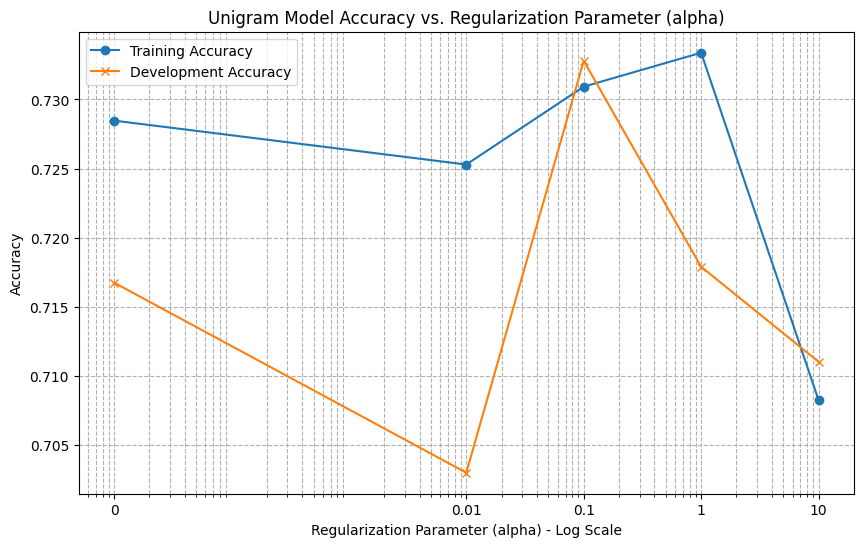

In [8]:
import matplotlib.pyplot as plt

regularization_params = [0, 0.01, 0.1, 1, 10]
unigram_train_accuracies_reg = []
unigram_dev_accuracies_reg = []

for alpha in regularization_params:
    print(f"\nTraining Unigram model with regularization parameter (alpha): {alpha}")
    reg_unigram_model = LogisticRegression(data_dim=vocab_size, reg_param=alpha,
                                       learning_rate=lr, training_tokens=training_unigram_features)

    for epoch in range(epochs):
        reg_unigram_model.SGD_update(stochastic_perc=0.1)

    final_train_acc = reg_unigram_model.accuracy(training_unigram_features)
    final_dev_acc = reg_unigram_model.accuracy(development_unigram_features)

    unigram_train_accuracies_reg.append(final_train_acc)
    unigram_dev_accuracies_reg.append(final_dev_acc)

    print(f"Final Unigram Training Accuracy (alpha={alpha}): {final_train_acc:.4f}")
    print(f"Final Unigram Development Accuracy (alpha={alpha}): {final_dev_acc:.4f}")

# Prepare data for plotting: replace 0 with a small positive number for log scale
plotting_reg_params = [p if p != 0 else 1e-5 for p in regularization_params]

plt.figure(figsize=(10, 6))
plt.plot(plotting_reg_params, unigram_train_accuracies_reg, marker='o', label='Training Accuracy')
plt.plot(plotting_reg_params, unigram_dev_accuracies_reg, marker='x', label='Development Accuracy')
plt.xscale('log') # Set x-axis to logarithmic scale
plt.title('Unigram Model Accuracy vs. Regularization Parameter (alpha)')
plt.xlabel('Regularization Parameter (alpha) - Log Scale')
plt.ylabel('Accuracy')

# Set custom x-ticks to display original labels, including '0'
plt.xticks(plotting_reg_params, labels=[str(p) for p in regularization_params])
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

### Training Loop

You should implement the logic for your model to train on the given training examples. Experiment with different hyperparameters to find the ones that optimize performance.

### Functions for evaluating model accuracy

### Download and load the training and development data

You can download the training and development sets for this problem from the links below:
*   Training data: https://princeton-nlp.github.io/cos484/assignments/a1/train.txt
*   Development data: https://princeton-nlp.github.io/cos484/assignments/a1/dev.txt

# Experiments

### Unigram vs Bigram (No regularization)
Code for sub-part (a)

**(a) In this part, we want to train the logistic regression model without regularization. Train your model separately with (i) unigram features and (ii) bigram features (two different models). Report both training and development accuracy on the dataset. How do the results of the unigram and bigram models compare?**

Final Unigram Training Accuracy: 0.7243

Final Unigram Development Accuracy: 0.7133

Final Bigram Training Accuracy: 0.7425

Final Bigram Development Accuracy: 0.6147

We notice that the unigram model generalizes a lot better to the unseen development set compared to the bigram model, so the bigram model likely overfits the task of sentiment analysis. Therefore, we can conclude that the unigram model is better at this task.


### Logistic regression with regularization

Code for sub-part (b)

**(b) Next, we would like to experiment with $l_2$ regularization $R(\theta) = \alpha\|\theta\|^2$. Plot the accuracy on train and development sets as a function of $\alpha = \{0, 10^{-2}, 10^{-1}, 1, 10\}$. You only need to experiment with unigram features for this part. Explain what you observe. Does this match what you would expect from regularization?**

Regularization does not significantly improve the performance of the model - we cannot even identify a clear trend in the accuracy of the model in terms of the regularization parameter. However, we could notice that a value for $\alpha$ in between 0.1 and 1 seems to lead to an increase in both the training and development accuracies.

**(c) Based on your model’s performance in the previous experiment, propose one change you would consider
making to either the model or feature extraction pipeline to further improve development set performance.
Briefly describe the modification, explain why you expect it will improve validation perplexity, and discuss any
potential limitations.**

There are many words such as "the," "and," "with," etc. that appear a lot in the datasets but that don't correlate much with either label. But since they're frequently encountered, they will skew the count-based feature vectors of the data (i.e. the values in the dimensions representing those words will be very high). Therefore, unless the model learns to minimize the weights associated with such words as much as possible by itself, their influence on the predicted label will be too high.

As such, one possible improvement could be to dismiss such words altogether when encountering them. This should remove noise from the data and thus improve the development accuracy. A limitation is knowing precisely how many words to disregard.

Another possible improvement could be to reduce the size and the sparsity of the feature vectors by using word embeddings. This would require a pre-training stage where we would obtain the word embeddings of the vocabulary.

# LLM Prompts

If you used an AI tool to complete any part of this assignment, please paste all prompts you used to produce your final code/responses in the box below and answer the following reflection question.

Prompts Used:
*   write me a block of code that explains the py.torch logistic regression main methods, including how to work with hyper parameters, number of epochs, etc. don't connect this to the given tasks in this assignment, I just need it to understand how I could use the py.torch library here
*   why does running the feactureextraction block lead to all my RAM being used
*   what's the ideal number of epochs to use in the gradient descent
*   can you create a loop that creates a unigram model for different values of the regularization parameter: 0, 0.01, 0.1, 1, 10 (same learning rate and epoch number as before) and calculates only the final train and development accuracies and plots them against values of the regularization parameter (make the plot semi-log)
*   the semilog axis is wrong, it plots the results weirdly - do it again, correctly




### Logistic regression with regularization
Code for sub-part (b)

**Reflection: What parts of the AI generated output required modification or improvement? Describe the feedback you gave the tool to produce your final output or any changes you had to make on your own.**

The only part that I noticed on the spot to be wrong was the final graph, but that was because I didn't realize I couldn't plot the 0 value on a log scale accurately, and then the AI assistant figured that out.
Another part that required redesign was the bigram extraction method. Initially, I stored the bigram vectors as very sparse matrices, but when I realized I didn't have enough RAM to store them like that I asked the AI how to solve the issue, and then it suggested using a more efficient data structure for sparse vectors.